In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings("ignore")

# Extract Historical Price Data

In [ ]:
# Placeholder ticker,add a list to extract a portfolio
ticker = "AAPL"

# Download historical data
df = yf.download(ticker, start="2015-01-01", end="2026-01-01")
df = df[["Close"]]

df.head()

# Visualize Price Data

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"])
plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# Scale The Data, Create Sequential Windows & Train-Test Split

In [ ]:
# Initialize scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Scale close prices
scaled_data = scaler.fit_transform(df)

scaled_data[:5]

sequence_length = 60

X, y = [], []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("X shape:", X.shape, "\ny shape:", y.shape)

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train), "\nTesting samples:", len(X_test))

# Build & Train The LSTM Model

In [ ]:
model = Sequential()

model.add(LSTM(units=64, return_sequences=True,
               input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Forecasts & Performance Metrics

In [16]:
# Forecast scaled values
predictions = model.predict(X_test)

# Inverse transform
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

predictions[:5]

mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
MAE  : 6.9575
RMSE : 8.9464


# Visuals

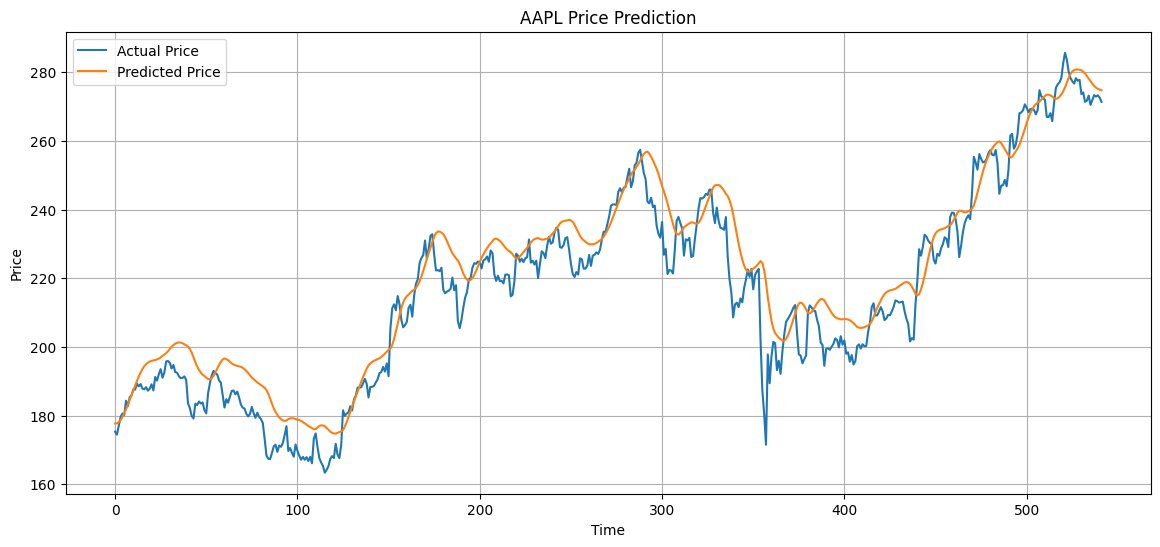

In [18]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title(f"{ticker} Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

# Export Data

In [ ]:
results = pd.DataFrame({
    "Actual": y_test_actual.flatten(),
    "Predicted": predictions.flatten()
})

results.to_csv("lstm_portfolio_forecasts.csv", index=False)

results.head()